## Business Case:

**The case business case is on the inventory management. Keeping
Inventory of spare in various service centre to the market demand is
always a challenge as most service centres spends significant amount
in spare parts inventory costs. In spite of this, availability of spare
parts is been one of the problem areas.**

## PROJECT GOAL:

**Create Predictive model for inventory forecasting so that
service centre achieve JIT standards.**


## Installing SQL

In [316]:
!pip install pymysql
!pip install mysql-connector

## Importing the Libraries

In [317]:
import os
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


## SQL Connection

In [318]:
connection=mysql.connector.connect(host='18.136.157.135',
                                  user=' dm_usdata_sql',
                                  password='37z<49REb&mKnl4AV!vJ',
                                  database='project_service_data')

## Loading The Dataset

In [319]:
df=pd.read_sql_query("select * from service_data",connection)

In [320]:
query="select * from service_data"
df=pd.read_sql(query,connection)

In [321]:
df.head()

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
0,30-05-17,30-05-17,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL
1,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL
2,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH
3,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,CONSUMABLES
4,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,COOLANT OIL


## Analysis of Data

In [322]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28482 entries, 0 to 28481
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   invoice_date           28482 non-null  object
 1   job_card_date          28482 non-null  object
 2   business_partner_name  28482 non-null  object
 3   vehicle_no             28482 non-null  object
 4   vehicle_model          28482 non-null  object
 5   current_km_reading     28482 non-null  object
 6   invoice_line_text      28476 non-null  object
dtypes: object(7)
memory usage: 1.5+ MB


**Checking for Null values**

In [323]:
df.isnull().sum()

,0
invoice_date,0
job_card_date,0
business_partner_name,0
vehicle_no,0
vehicle_model,0
current_km_reading,0
invoice_line_text,6


**Drop rows with missing values**

In [324]:
df.dropna(inplace = True)

In [325]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28476 entries, 0 to 28481
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   invoice_date           28476 non-null  object
 1   job_card_date          28476 non-null  object
 2   business_partner_name  28476 non-null  object
 3   vehicle_no             28476 non-null  object
 4   vehicle_model          28476 non-null  object
 5   current_km_reading     28476 non-null  object
 6   invoice_line_text      28476 non-null  object
dtypes: object(7)
memory usage: 1.7+ MB


**Summary Statistics**

In [326]:
df.describe()

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
count,28476,28476,28476,28476,28476,28476,28476
unique,555,553,1010,846,28,3474,503
top,01-12-18,01-12-18,venkXXXXXXXXXX,KA53EVXXXX,BAJAJ PULSAR 150,0,ENGINE OIL
freq,179,179,424,1313,8631,842,3802


In [327]:
# Converting job_card_date to date format
df['job_card_date'] = pd.to_datetime(df['job_card_date'], format='%d-%m-%y')

In [328]:
df['week'] = df['job_card_date'].dt.isocalendar().week
df['year'] = df['job_card_date'].dt.year

In [329]:
# Select relevant columns
df = df[['job_card_date', 'vehicle_model', 'invoice_line_text', 'year', 'week']]

## Exploratory Data Analysis EDA

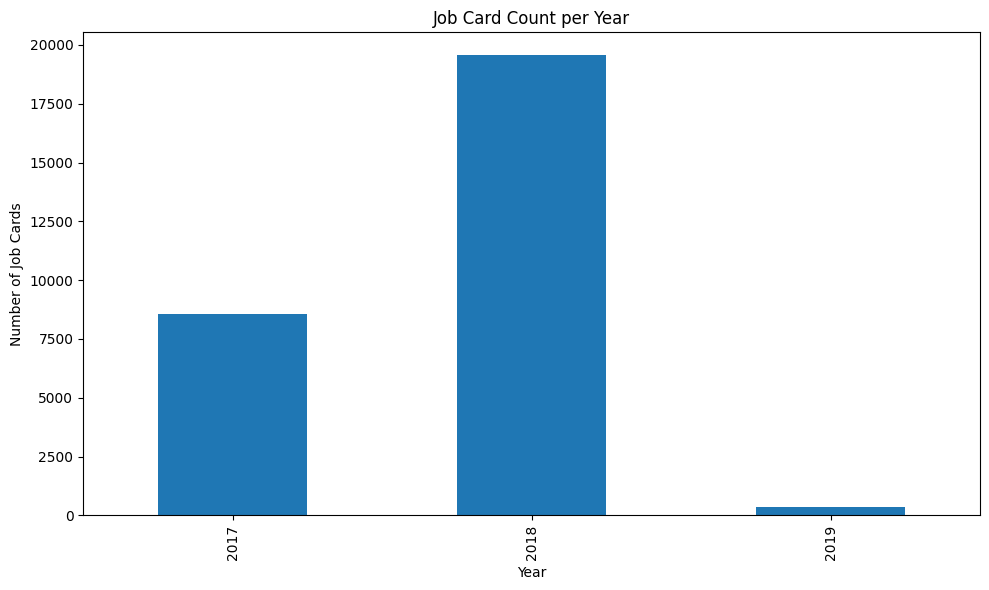

In [330]:
# Date Distribution
plt.figure(figsize=(10, 6))
df['job_card_date'].dt.year.value_counts().sort_index().plot(kind='bar', title="Job Card Count per Year")
plt.xlabel("Year")
plt.ylabel("Number of Job Cards")
plt.tight_layout()
plt.show()

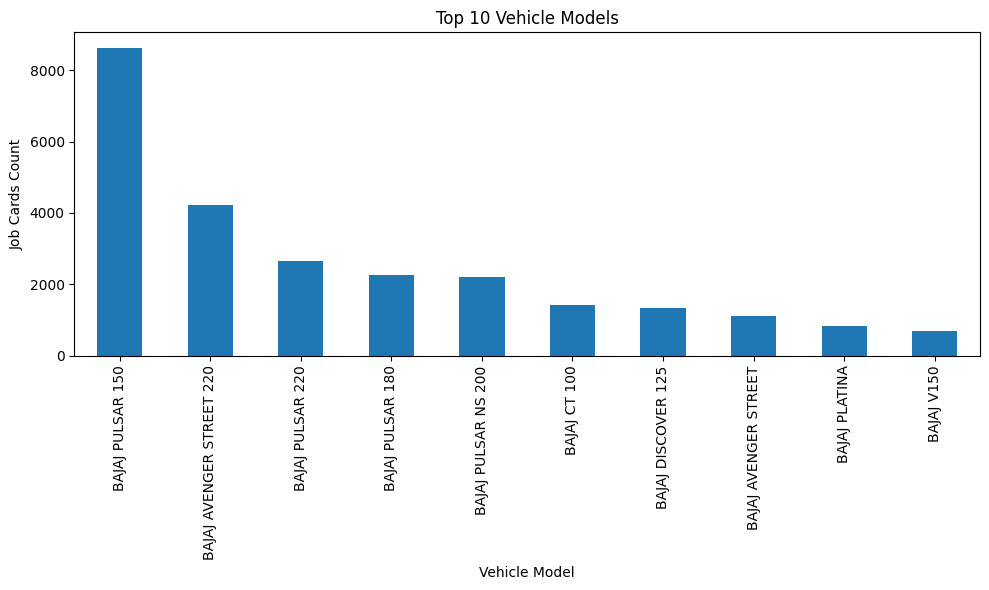

In [331]:
# Top Vehicle Models
plt.figure(figsize=(10, 6))
df['vehicle_model'].value_counts().head(10).plot(kind='bar', title="Top 10 Vehicle Models")
plt.xlabel("Vehicle Model")
plt.ylabel("Job Cards Count")
plt.tight_layout()
plt.show()

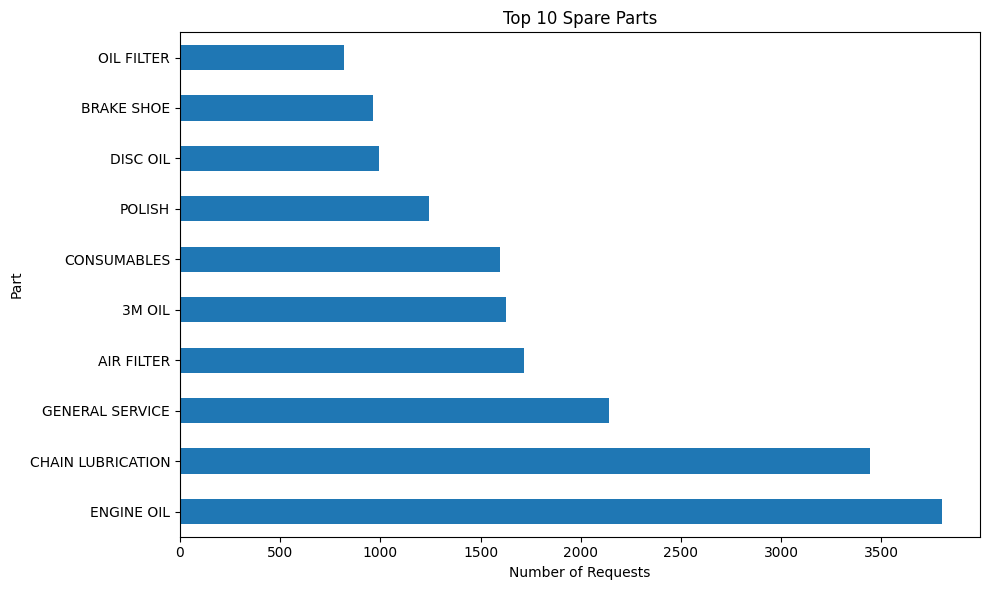

In [332]:
# Top Requested Parts
plt.figure(figsize=(10, 6))
df['invoice_line_text'].value_counts().head(10).plot(kind='barh', title="Top 10 Spare Parts")
plt.xlabel("Number of Requests")
plt.ylabel("Part")
plt.tight_layout()
plt.show()


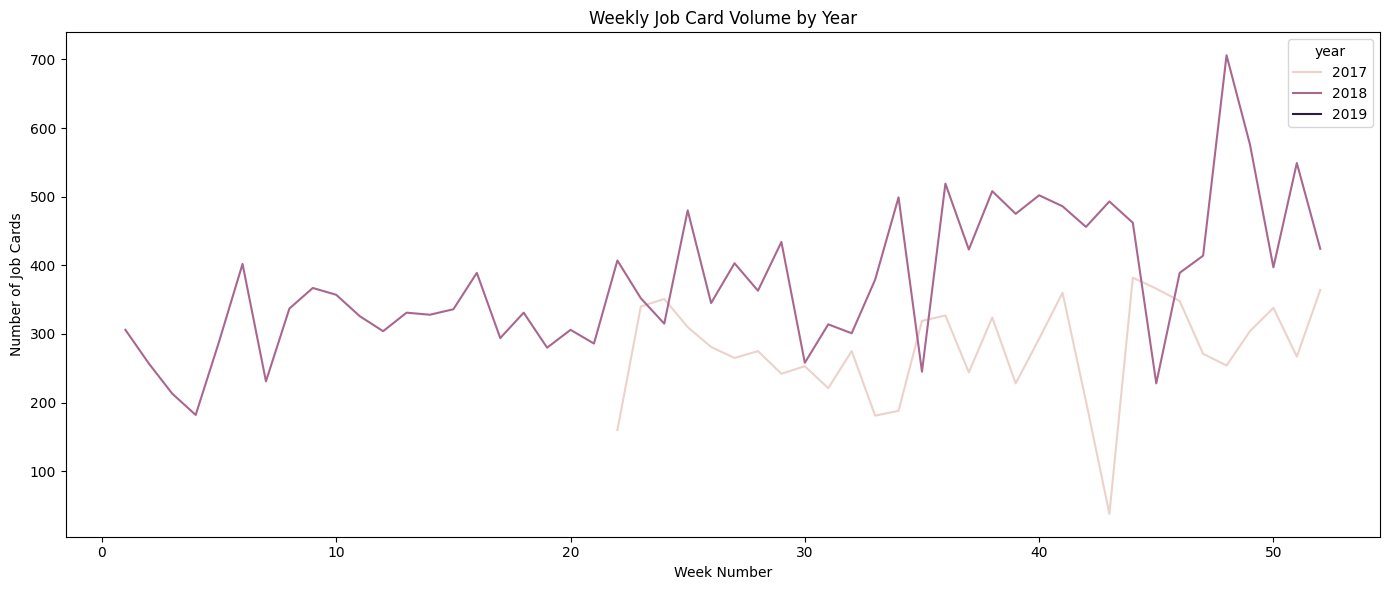

In [333]:
# Weekly Seasonality Analysis
weekly_trend = df.groupby(['year', 'week']).size().reset_index(name='weekly_jobs')
plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_trend, x='week', y='weekly_jobs', hue='year')
plt.title("Weekly Job Card Volume by Year")
plt.xlabel("Week Number")
plt.ylabel("Number of Job Cards")
plt.tight_layout()

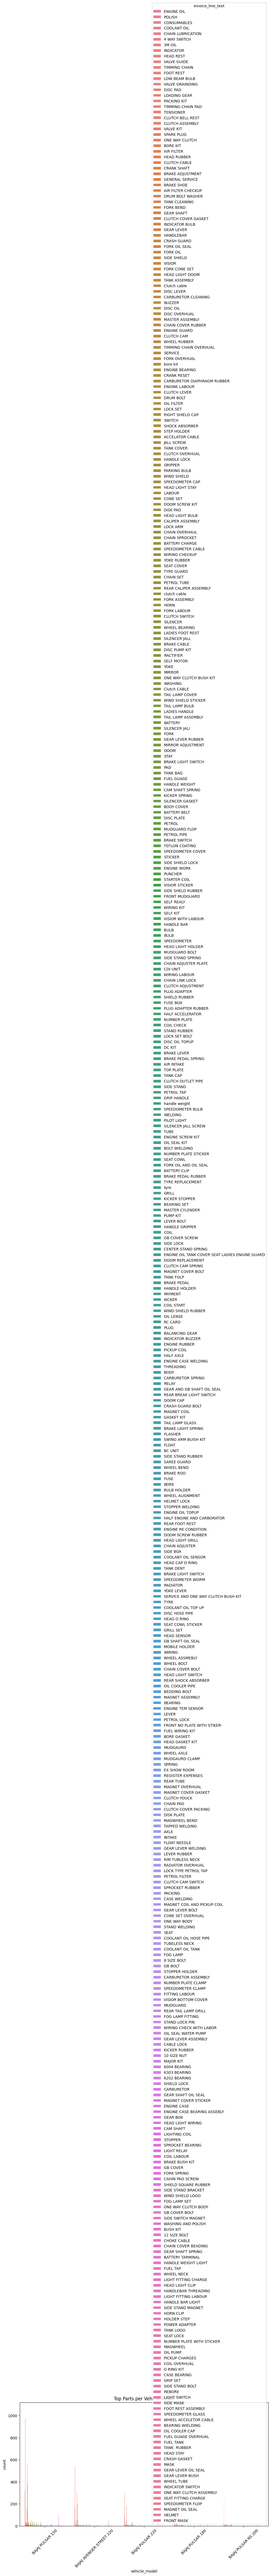

In [334]:
# Spare Parts vs. Vehicle Model
top_models = df['vehicle_model'].value_counts().nlargest(5).index
subset = df[df['vehicle_model'].isin(top_models)]
plt.figure(figsize=(12, 6))
sns.countplot(data=subset, x='vehicle_model', hue='invoice_line_text', order=top_models)
plt.title("Top Parts per Vehicle Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Demand aggregation by year, week, vehicle model, and part**

In [335]:
df = df.groupby(['year', 'week', 'vehicle_model', 'invoice_line_text']).size().reset_index(name='demand')

**Converting Categorical Data to Numberical Data**

In [336]:
from sklearn.preprocessing import LabelEncoder
le_vm = LabelEncoder()
le_part = LabelEncoder()
df['vehicle_model_enc'] = le_vm.fit_transform(df['vehicle_model'])
df['part_enc'] = le_part.fit_transform(df['invoice_line_text'])

## Modeling

In [337]:
X = df[['year', 'week', 'vehicle_model_enc', 'part_enc']]
y = df['demand']

In [338]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**XGBoost**

In [339]:
from xgboost import XGBRegressor
XGB = XGBRegressor(n_estimators=100, random_state=42)
XGB.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [340]:
y_pred_XGB = XGB.predict(X_test)

In [341]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [342]:
print("XGBoost : ")
print ("R2 Score : ",r2_score(y_test,y_pred_XGB))

rmse_xgb = mean_squared_error(y_test, y_pred_XGB)
print(f'RMSE: {rmse_xgb:.2f}')


XGBoost : 
R2 Score :  0.6483543515205383
RMSE: 1.33


**Random Forest**

In [343]:
from sklearn.ensemble import RandomForestRegressor
RF = RandomForestRegressor(n_estimators=100, random_state=42)
RF.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [344]:
y_pred_RF = RF.predict(X_test)

In [345]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_RF))

print('Random Forest :')
print('R2 Score: ',r2_score(y_test,y_pred_RF))
print(f"RMSE: {rmse_rf:.2f}")

Random Forest :
R2 Score:  0.596534910023659
RMSE: 1.23


**LGBMRegressor**

In [346]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(n_estimators=100, random_state=42)
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000572 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in the train set: 11826, number of used features: 4
[LightGBM] [Info] Start training from score 1.932352


LGBMRegressor(random_state=42)

In [347]:
y_pred_lgb = lgb_model.predict(X_test)

In [348]:
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))

print('LGBMRegressor :')
print('R2 Score: ',r2_score(y_test, y_pred_lgb))
print(f"RMSE: {rmse_lgb:.2f}")

LGBMRegressor :
R2 Score:  0.6719628063617815
RMSE: 1.11


## Hyperparameter optimization

**XGBoost**

In [349]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

xgb = XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,  # Number of random parameter combinations to try
    scoring='neg_root_mean_squared_error',  # Use RMSE for scoring
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters found: ", random_search.best_params_)
print("Best RMSE (neg): ", random_search.best_score_)

# Use the best estimator to predict
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print(f"Tuned XGBoost RMSE: {rmse_best:.2f}")
print(f"Tuned XGBoost R2: {r2_best:.3f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters found:  {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best RMSE (neg):  -1.205369234085083
Tuned XGBoost RMSE: 1.16
Tuned XGBoost R2: 0.641


**Random Florest**

In [350]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

print("Best RF params:", random_search_rf.best_params_)
print("Best RF RMSE (neg):", random_search_rf.best_score_)

best_rf = random_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Tuned RF RMSE: {rmse_rf:.2f}")
print(f"Tuned RF R2: {r2_rf:.3f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}
Best RF RMSE (neg): -1.2870443213499152
Tuned RF RMSE: 1.18
Tuned RF R2: 0.630


**LGBMRegressor**

In [351]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

lgb = LGBMRegressor(random_state=42)

param_dist_lgb = {
    'num_leaves': [31, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'max_depth': [-1, 10, 20],
    'min_child_samples': [20, 30, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

random_search_lgb = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=param_dist_lgb,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_lgb.fit(X_train, y_train)

print("Best LGB params:", random_search_lgb.best_params_)
print("Best LGB RMSE (neg):", random_search_lgb.best_score_)

best_lgb = random_search_lgb.best_estimator_
y_pred_lgb = best_lgb.predict(X_test)

rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2_lgb = r2_score(y_test, y_pred_lgb)

print(f"Tuned LGB RMSE: {rmse_lgb:.2f}")
print(f"Tuned LGB R2: {r2_lgb:.3f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000507 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in the train set: 11826, number of used features: 4
[LightGBM] [Info] Start training from score 1.932352
Best LGB params: {'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best LGB RMSE (neg): -1.1538716726790321
Tuned LGB RMSE: 1.07
Tuned LGB R2: 0.695


#### Selecting the Best Model

In [352]:
models_score = pd.DataFrame({'R2 Score':[r2_best,r2_rf,r2_lgb],'Mean Absolute Error':[rmse_best,rmse_rf,rmse_lgb]}, index=['XGBoost','Random forest','LGBMRegressor'])
models_score

,R2 Score,Mean Absolute Error
XGBoost,0.640530,1.164115
Random forest,0.630000,1.181041
LGBMRegressor,0.695417,1.071562


## Conclusion
After the parameter tuning process with XGBoosting,Random Forest and LGBMRegressor I decided to select the LGBMRegressor Model as it gives the least value of Mean Absolute Error as lower value of Mean Absolute Error is better and Higher R2 Score is better.